In [1]:
import torch
from data.fastmri import MRIReconstructionDataset  # Replace with your actual file
from utils.recon_funcs import project_to_coils,CGDataConsistency,cg_data_consistency, estimate_object_mask
from utils.models import UNet
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Load data
data_dir = '/auto/data2/salman/datasets/fastMRI_brain_20coils_T2_640x320_training/uniform/'
test_dataset = MRIReconstructionDataset(data_root=data_dir, split='test')

#Define and load model
device='cuda'
model = UNet()
model.load_state_dict(torch.load( "unet.pth"))
model.to(device)
model.eval()

cg_layer = CGDataConsistency(max_iter=10)
cg_layer.load_state_dict(torch.load( "cg.pth"))
cg_layer.to(device)
cg_layer.eval()

CGDataConsistency()

In [7]:
#Load test sample
sample_no = 65
sample = test_dataset.__getitem__(sample_no)
combined_us = sample['combined_us'].unsqueeze(0).to(device) # Coil combined ZF
combined_full = sample['combined_full'].unsqueeze(0).to(device) # Coil combined ground truth
us_coil = sample['us_coil'].unsqueeze(0).to(device) # Multi-coil ZF
sensitivity = sample['sensitivity'].unsqueeze(0).to(device) # Coil sensitivity maps
mask = sample['mask'].unsqueeze(0).unsqueeze(0).to(device) # Undersampling masks


In [8]:
iterations = 5 # unrolling iterations
lbmda = next(cg_layer.parameters()).item() # Learned during training, you can try value of your own choice and see how performance changes
x = combined_us
with torch.no_grad():
    for _ in range(iterations):
        x_pre = model(x) # DL prior
        projected = project_to_coils(x_pre, sensitivity) # projection onto multipe coils
        x = cg_data_consistency(x_pre, us_coil, sensitivity, mask, lam=lbmda, max_iter=10, tol=1e-6) # DC throgh CG
        x = x * estimate_object_mask(sensitivity) # Removing background               
    

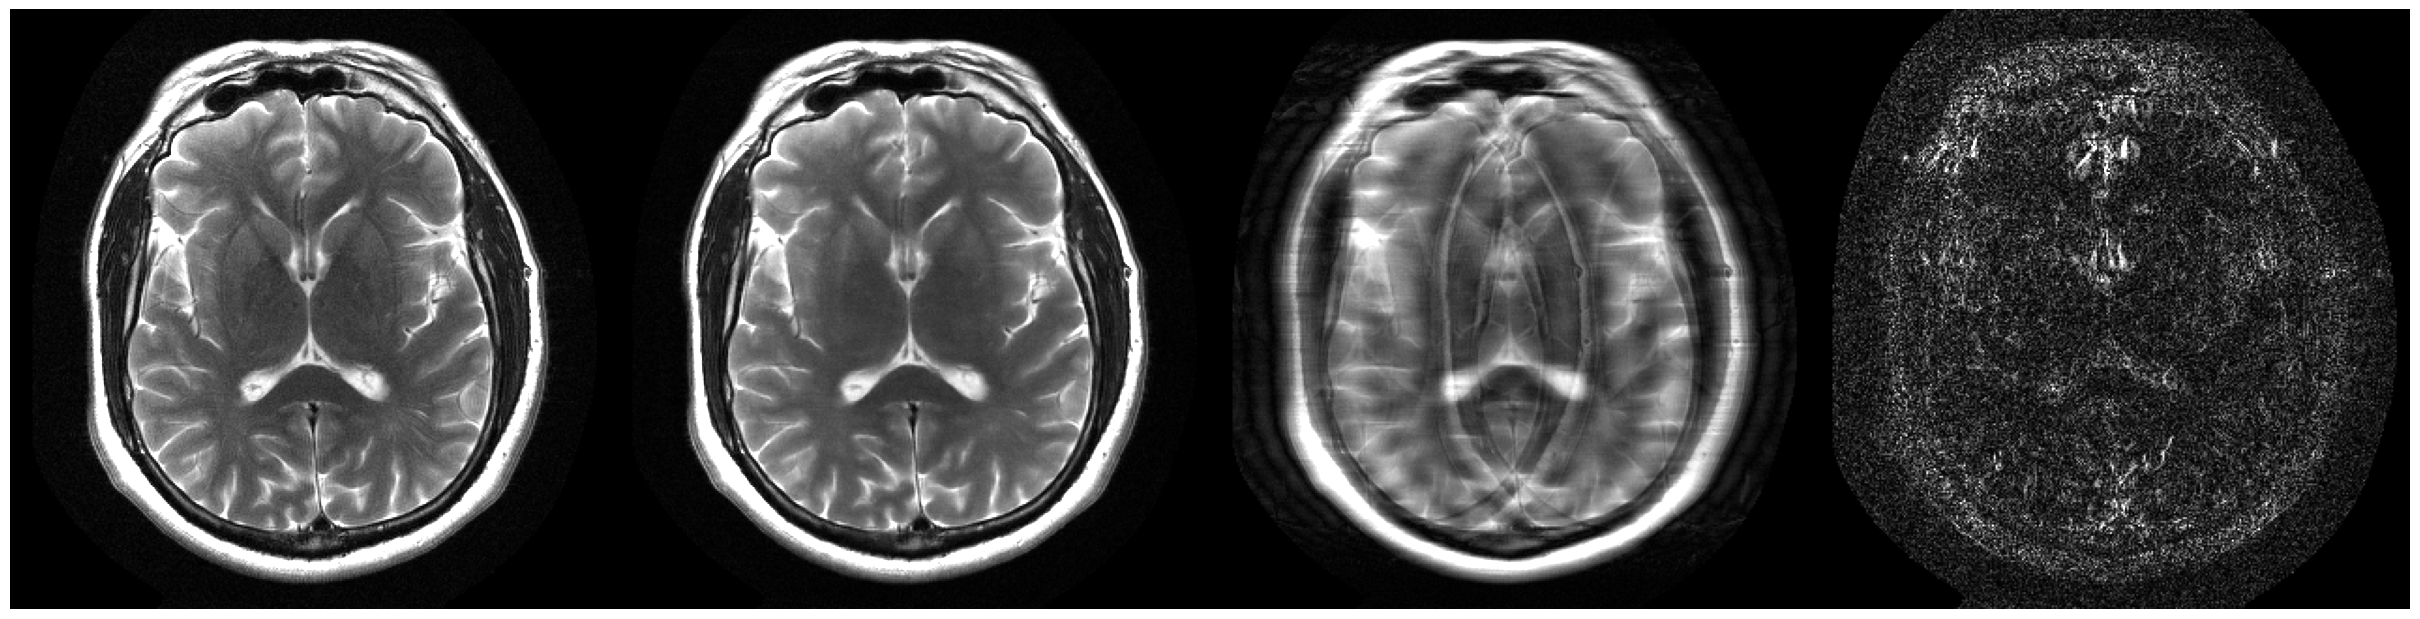

In [12]:
# Convert torch tensors to numpy arrays
fs = torch.view_as_complex(combined_full.permute(0, 2, 3, 1)).squeeze().cpu().numpy()# Coil combined ground truth
us = torch.view_as_complex(combined_us.permute(0, 2, 3, 1)).squeeze().cpu().numpy()# Coil combined ZF
rec = torch.view_as_complex(x.permute(0,2,3,1).contiguous()).squeeze().cpu().numpy()# CCoil ccombined reconstruction

# Displaying images
fig = plt.figure(figsize=(24, 8)) 
plt.subplot(1, 4, 1)
plt.imshow(np.flipud(abs(fs)), cmap='gray', vmax=0.7);plt.axis('off') 
plt.subplot(1, 4, 2)
plt.imshow(np.flipud(abs(rec)), cmap='gray', vmax=0.7);plt.axis('off') 
plt.subplot(1, 4, 3)
plt.imshow(np.flipud(abs(us)), cmap='gray', vmax=0.7);plt.axis('off') 
plt.subplot(1, 4, 4)
plt.imshow(np.flipud(abs(abs(rec)-abs(fs))), vmax = 0.1,cmap='gray');plt.axis('off') 
plt.tight_layout(pad=0)


In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

def nrmse(img1, img2):
    # Compute the RMSE
    rmse = np.sqrt(np.mean(np.abs(img1 - img2) ** 2))
    
    # Compute the mean of img2
    mean_img2 = np.sqrt(np.mean(np.abs(img2) ** 2))
    
    # Compute the NRMSE
    nrmse_value = 100 * rmse / mean_img2
    
    return nrmse_value

# Calculate Percentage RMSE
percentage_rmse = nrmse(rec,fs)

print(f"Percentage RMSE: {percentage_rmse:.2f}%")

Percentage RMSE: 8.61%


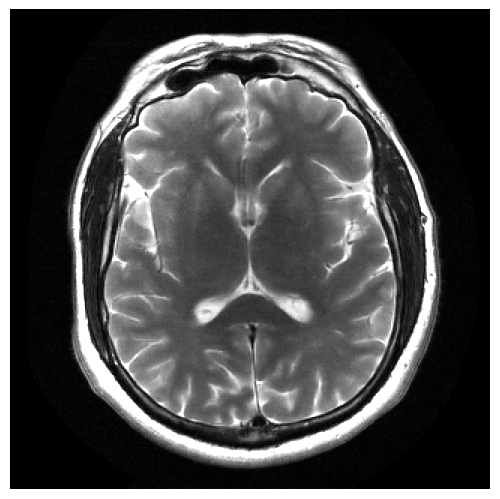

In [13]:
plt.figure()
plt.imshow(np.flipud(abs(rec)), cmap='gray', vmax=0.7)
plt.axis('off')  # Removes ticks and labels
plt.tight_layout(pad=0)
plt.savefig('rec.png', dpi=300,bbox_inches='tight', pad_inches=0)
